# Generative Models, Part 1 — From Random Experiments to Probability Distribution

Before we build generators (VAEs, and diffusion models), we need a clean mental model of **data** and **probability**. In this first part, we’ll:

1. See data as outcomes of **random experiments** (coin tosses, die rolls, camera captures).
2. Ask how to predict **future outcomes** and why probability enters.
3. Use the **Law of Large Numbers** (LLN) to estimate probabilities from data.
4. Connect repeated outcomes to **distributions** and **probability density / mass functions**.
5. Bridge the ideas to **image datasets**.

---

## 1. Data are outcomes of random experiments

A **random experiment** is any repeatable procedure with uncertain outcome:
- Flip a fair coin → `Heads` or `Tails`
- Roll a six-sided die → `1…6`
- Press a camera shutter → an image (affected by scene, lighting, sensor noise, motion, etc.)

When we **repeat** the experiment, we collect **data**: a list (or array) of outcomes.

### Example: A couple of experiments (data as outcomes)

In [1]:
import random

def flip_coin():
    return "H" if random.random() < 0.5 else "T"

def roll_die():
    return random.randint(1, 6)

# Generate data
coin_data = [flip_coin() for _ in range(20)]
die_data  = [roll_die() for _ in range(20)]

print("Experiment 1 outcomes:", coin_data)
print("Experiment 2 outcomes:", die_data)

Experiment 1 outcomes: ['H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'T', 'H', 'T', 'H', 'H', 'H', 'H', 'H', 'T', 'T']
Experiment 2 outcomes: [6, 5, 2, 1, 1, 2, 5, 3, 1, 3, 3, 3, 1, 6, 1, 5, 6, 2, 5, 2]


## 2. Predicting the next outcome ⇒ introduce probability

**Question:** *If I flip again, what will I get?*

We generally can’t **deterministically** predict a single flip. But if we ask, *what’s the chance the next flip is Heads?* we need a **probability**. For a fair coin, $( P(\text{H}) = 0.5 )$. For a fair die, $( P(k) = 1/6 )$.

But what if the coin/die might be **biased**? We **estimate** probabilities from data.

## 3. Estimating probabilities from data: the Law of Large Numbers

The **Law of Large Numbers (LLN)** says: as the number of independent repeats (n) grows, the **empirical frequency** converges to the true probability.

Let’s watch it happen.

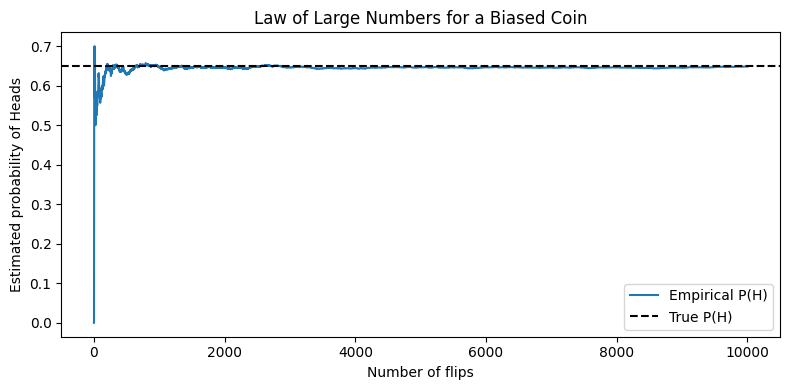

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(0)

def flip_coin(p=0.5):
    return 1 if random.random() < p else 0  # 1=H, 0=T

def empirical_convergence(p=0.5, trials=10_000):
    xs = np.zeros(trials, dtype=int)
    for i in range(trials):
        xs[i] = flip_coin(p)
    cum_mean = np.cumsum(xs) / (np.arange(trials) + 1)
    return cum_mean

p_true = 0.65          # try a biased coin!
cum_mean = empirical_convergence(p=p_true, trials=10000)

plt.figure(figsize=(8,4))
plt.plot(cum_mean, label="Empirical P(H)")
plt.axhline(p_true, color="k", linestyle="--", label="True P(H)")
plt.xlabel("Number of flips")
plt.ylabel("Estimated probability of Heads")
plt.title("Law of Large Numbers for a Biased Coin")
plt.legend()
plt.tight_layout()
plt.show()

As sample size grows, the running estimate approaches the true value.

---

## 4. From outcomes to distributions

A **distribution** describes how outcomes are spread.

* Discrete outcomes → **probability mass function (PMF)** $(P(X=x))$
* Continuous outcomes → **probability density function (PDF)** $(p(x))$, where probabilities are areas under the curve.

### 4.1 Discrete distributions (die)

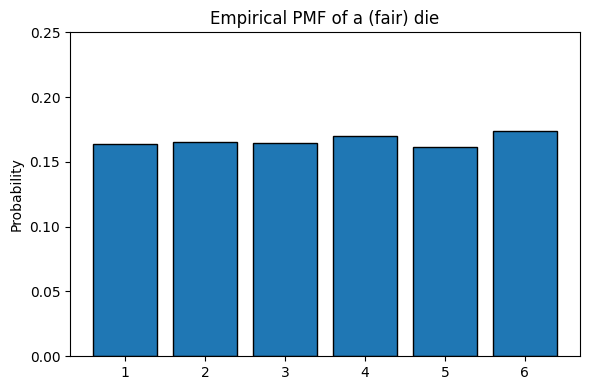

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
die_rolls = [random.randint(1,6) for _ in range(20_000)]

# Empirical PMF
vals, counts = np.unique(die_rolls, return_counts=True)
pmf = counts / counts.sum()

plt.figure(figsize=(6,4))
plt.bar(vals, pmf, edgecolor="k")
plt.xticks([1,2,3,4,5,6])
plt.ylim(0, 0.25)
plt.ylabel("Probability")
plt.title("Empirical PMF of a (fair) die")
plt.tight_layout()
plt.show()

With enough samples, each bar approaches (1/6).

### 4.2 Continuous distributions (heights, sensor noise, pixel intensities)

Suppose we sample real numbers from a mixture of Gaussians (a simple model of “multi-mode” data).

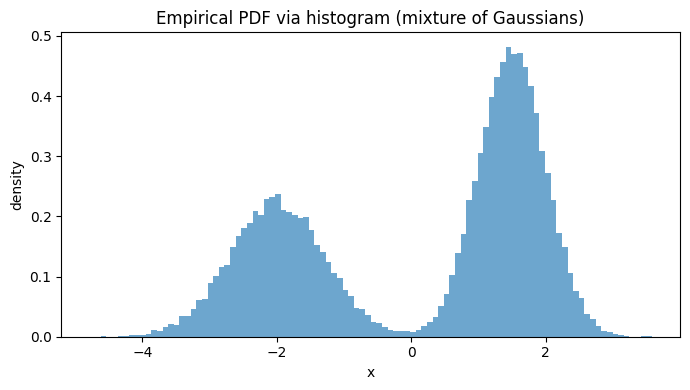

In [4]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

n = 50_000
# Mixture of 2 Gaussians: w*N(μ1,σ1^2) + (1-w)*N(μ2,σ2^2)
w   = 0.4
mu1, sig1 = -2.0, 0.7
mu2, sig2 =  1.5, 0.5

z = rng.random(n)
x = np.where(
    z < w,
    rng.normal(mu1, sig1, n),
    rng.normal(mu2, sig2, n)
)

plt.figure(figsize=(7,4))
plt.hist(x, bins=100, density=True, alpha=0.65, edgecolor="none")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Empirical PDF via histogram (mixture of Gaussians)")
plt.tight_layout()
plt.show()


> The histogram is a **non-parametric** density estimate. With different bin widths you get coarser/finer approximations.

If you want a smoother non-parametric estimate, use **KDE**:

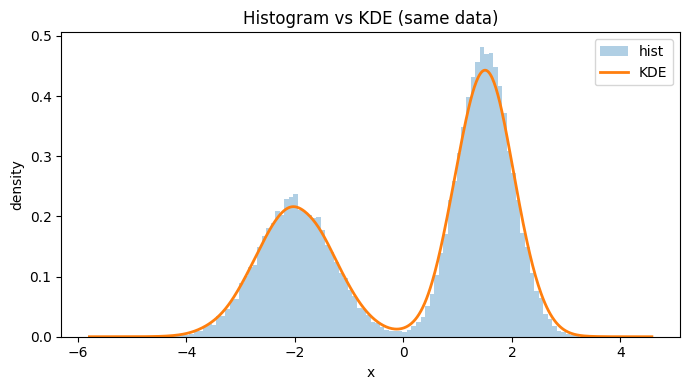

In [5]:
from scipy.stats import gaussian_kde

xs = np.linspace(x.min()-1, x.max()+1, 600)
kde = gaussian_kde(x)
plt.figure(figsize=(7,4))
plt.hist(x, bins=100, density=True, alpha=0.35, edgecolor="none", label="hist")
plt.plot(xs, kde(xs), lw=2, label="KDE")
plt.xlabel("x"); plt.ylabel("density"); plt.legend()
plt.title("Histogram vs KDE (same data)")
plt.tight_layout()
plt.show()

## 5. What does this have to do with images?

An image is a high-dimensional random vector:

$$
\mathbf{x}\in [0,1]^{H\times W\times C}
$$

Each time you press the shutter, you draw **one sample** $( \mathbf{x} )$ from some (unknown) distribution over images $(p_{\text{data}}(\mathbf{x}))$. That distribution captures:

* The **content** distribution (what scenes occur),
* **Illumination** variation,
* **Sensor noise** and optics,
* **Composition** biases, etc.

We can look at **marginal** distributions (e.g., pixel intensities) to get a feel.

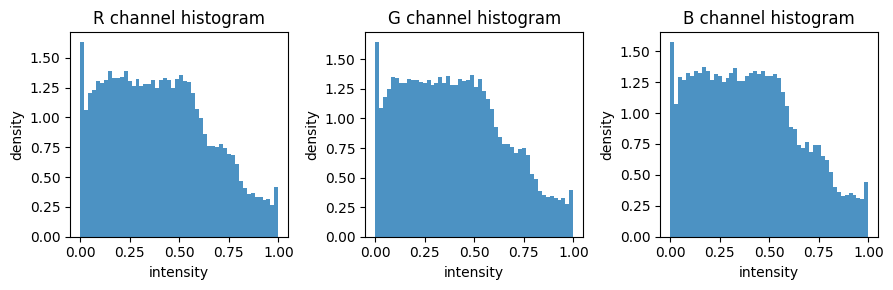

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Fake "dataset": three synthetic images with different brightness/color
rng = np.random.default_rng(1)
H, W, C = 128, 128, 3
imgs = []
for k in range(3):
    base = rng.random((H, W, C)) * (0.6 + 0.4 * k/2)  # brighter as k increases
    noise = rng.normal(0, 0.03, (H, W, C))
    img = np.clip(base + noise, 0, 1)
    imgs.append(img)

stack = np.concatenate([im.reshape(-1, C) for im in imgs], axis=0)  # N x 3
r, g, b = stack[:,0], stack[:,1], stack[:,2]

plt.figure(figsize=(9,3))
for i, (ch, name) in enumerate([(r,"R"), (g,"G"), (b,"B")], 1):
    plt.subplot(1,3,i)
    plt.hist(ch, bins=50, range=(0,1), density=True, alpha=0.8, edgecolor="none")
    plt.title(f"{name} channel histogram")
    plt.xlabel("intensity"); plt.ylabel("density")
plt.tight_layout()
plt.show()

These histograms are **1D marginals** of the full image distribution. They are **not** enough to describe images (they miss spatial structure and cross-channel dependencies), but they demonstrate the same principle: **data arise from an underlying distribution**, and we estimate aspects of that distribution by **counting** or **smoothing** over many samples.

## 6. Key notions to carry forward

* **Random experiment → data**: Every datapoint is an outcome of a stochastic process.
* **Probability connects past to future**: We don’t predict individual outcomes, we reason about **likelihoods**.
* **Law of Large Numbers**: Empirical frequencies/densities converge to true probabilities/densities with many samples.
* **Distributions**:

  * **PMF** for discrete variables (die, words, categories).
  * **PDF** for continuous variables (height, pixel intensity).
  * **Mixtures** model multi-modal data (e.g., faces with/without glasses, digits 0–9).
* **Images** are high-dimensional draws from $(p_{\text{data}}(\mathbf{x}))$. Understanding/generating images means modeling (or sampling from) that distribution.

---

## Up next (Part 2)

With this foundation, we’ll step into **generative paradigms**—how models learn $(p_{\text{data}})$ or a good proxy:

* **Latent-Variable Models / VAEs** (learn a latent prior + decoder),
* **Autoregressive** models (factorize the joint),
* **Normalizing Flows** (invertible maps with exact likelihood),
* **Diffusion** models (learn to denoise and sample).

We’ll start with VAEs and build up to diffusion, tying each method back to the distribution view you just built.